#  Car Crash Severity Prediction
### Machine Learning Classification Project

**Target:** `Severity` — 3 classes: `Minor Injury` · `Severe Injury` · `Fatal`

**Models:** KNN · Decision Tree · Random Forest · Logistic Regression · Naïve Bayes

---
**Dataset facts (pre-inspected):**
- Train: **4,000 rows × 19 columns** (18 features + Severity)
- Test : **1,000 rows × 19 columns**
- Only **one column has missing values**: `Distraction Level` (~59% in train)
- **No numeric outliers** via IQR — all values are physically plausible
- **Class imbalance**: Minor Injury 68.9% · Severe Injury 26.0% · Fatal 5.2%

##  Cell 1 – Imports

In [183]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, copy
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import balanced_accuracy_score
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, f1_score, roc_auc_score, roc_curve
)

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
RANDOM_STATE = 42
print('All libraries imported ✅')

All libraries imported ✅


##  Cell 2 – Load Data

In [184]:
train = pd.read_csv('car_crash_train.csv')
test  = pd.read_csv('car_crash_test.csv')
sub   = pd.read_csv('sample_submission.csv')
TARGET = 'Severity'
severity_order = ['Minor Injury', 'Severe Injury', 'Fatal']
CLASS_NAMES    = severity_order
print(f'Train: {train.shape} | Test: {test.shape}')
train.head()

Train: (4000, 19) | Test: (1000, 19)


,Crash Speed (km/h),Impact Angle (degrees),Airbag Deployed,Seatbelt Used,Weather Conditions,Road Conditions,Crash Type,Vehicle Type,Vehicle Age (years),Brake Condition,Tire Condition,Driver Age,Driver Experience (years),Alcohol Level (BAC%),Distraction Level,Time of Day,Traffic Density,Visibility Distance (m),Severity
0,182,69,Yes,No,Clear,Dry,Rollover,Sedan,5,Good,Good,23,11,0.025314,NaN,Morning,Low,213,Minor Injury
1,192,73,Yes,No,Clear,Dry,Head-on,Truck,3,Good,Good,29,27,0.002372,Phone,Morning,Medium,426,Minor Injury
2,114,77,No,Yes,Clear,Dry,Head-on,Sedan,16,Good,Worn out,73,45,0.000483,NaN,Morning,Medium,175,Minor Injury
3,93,14,No,Yes,Clear,Dry,Rear-end,Truck,14,Worn out,Worn out,27,18,0.176578,NaN,Afternoon,Medium,82,Minor Injury
4,170,96,No,Yes,Clear,Dry,Side impact,SUV,15,Good,Good,70,27,0.065696,Other,Morning,Medium,96,Severe Injury


---
##  Section 1 – Exploratory Data Analysis (EDA)

### Cell 3 – Dataset Overview & Statistics

In [185]:
print('=== TRAIN INFO ===')
train.info()
print('\n=== Numeric Statistics ===')
train.describe().T

=== TRAIN INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Crash Speed (km/h)         4000 non-null   int64  
 1   Impact Angle (degrees)     4000 non-null   int64  
 2   Airbag Deployed            4000 non-null   object 
 3   Seatbelt Used              4000 non-null   object 
 4   Weather Conditions         4000 non-null   object 
 5   Road Conditions            4000 non-null   object 
 6   Crash Type                 4000 non-null   object 
 7   Vehicle Type               4000 non-null   object 
 8   Vehicle Age (years)        4000 non-null   int64  
 9   Brake Condition            4000 non-null   object 
 10  Tire Condition             4000 non-null   object 
 11  Driver Age                 4000 non-null   int64  
 12  Driver Experience (years)  4000 non-null   int64  
 13  Alcohol Level (BAC%)       40

,count,mean,std,min,25%,50%,75%,max
Crash Speed (km/h),4000.0,110.999750,52.227839,20.000000,66.00000,112.000000,157.000000,199.000000
Impact Angle (degrees),4000.0,89.979750,51.301514,0.000000,45.00000,89.500000,134.000000,179.000000
Vehicle Age (years),4000.0,9.445500,5.718147,0.000000,5.00000,9.000000,14.000000,19.000000
Driver Age,4000.0,48.698750,17.815972,18.000000,34.00000,49.000000,64.000000,79.000000
Driver Experience (years),4000.0,24.723000,14.211818,0.000000,13.00000,25.000000,37.000000,49.000000
Alcohol Level (BAC%),4000.0,0.101216,0.057820,0.000054,0.05063,0.101574,0.151783,0.199936
Visibility Distance (m),4000.0,247.583500,143.478155,10.000000,120.00000,244.000000,372.000000,499.000000


### Cell 4 – Missing Values

=== Missing Values ===
                   Train Missing  Train %  Test Missing  Test %
Distraction Level           2360     59.0           603    60.3


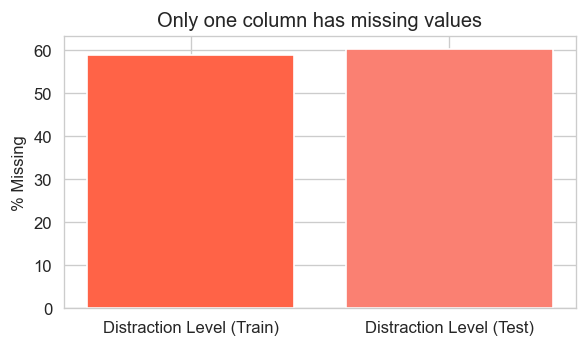


💬 Observation:
  Only 'Distraction Level' has missing values (~59% train, ~60% test).
  NaN does NOT mean data corruption — it means NO distraction was recorded.
  Strategy: fill NaN with a new category 'None'  (not drop, not impute with mode).



In [186]:
miss_train = train.isnull().sum()
miss_test  = test.isnull().sum()
miss_df = pd.DataFrame({'Train Missing': miss_train, 'Train %': (miss_train/len(train)*100).round(1),
                        'Test Missing' : miss_test,  'Test %' : (miss_test /len(test) *100).round(1)})
print('=== Missing Values ===')
print(miss_df[miss_df['Train Missing'] > 0])

fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(['Distraction Level (Train)', 'Distraction Level (Test)'],
       [miss_train['Distraction Level']/len(train)*100,
        miss_test['Distraction Level']/len(test)*100],
       color=['tomato','salmon'], edgecolor='white')
ax.set_ylabel('% Missing')
ax.set_title('Only one column has missing values')
plt.tight_layout(); plt.show()

print("""
💬 Observation:
  Only 'Distraction Level' has missing values (~59% train, ~60% test).
  NaN does NOT mean data corruption — it means NO distraction was recorded.
  Strategy: fill NaN with a new category 'None'  (not drop, not impute with mode).
""")

### Cell 5 – Target Variable Distribution

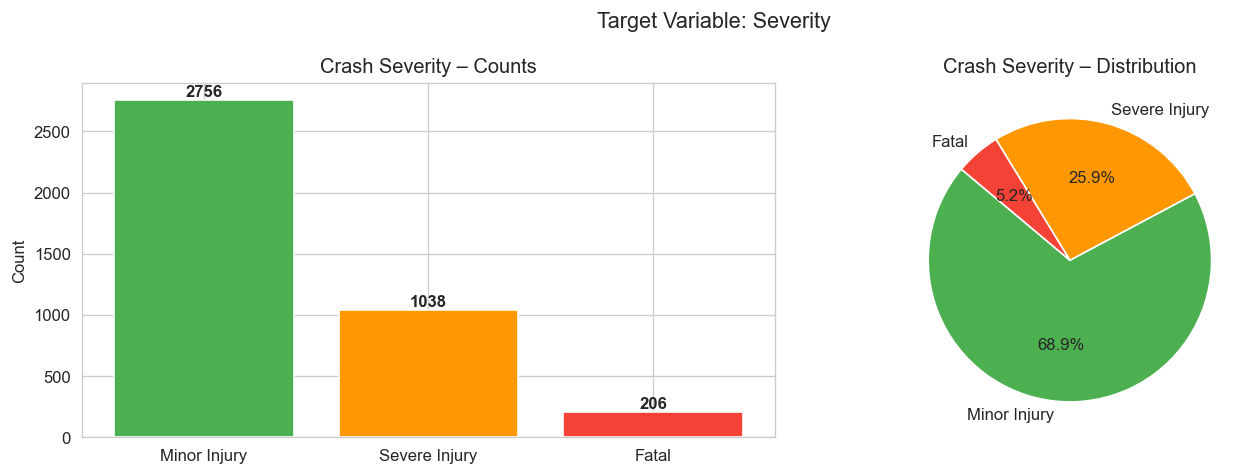


💬 Class Imbalance:
  Minor Injury : 68.9%  (dominant)
  Severe Injury: 26.0%
  Fatal        :  5.2%  (critical minority)

  → Accuracy alone is misleading (always predicting Minor = 69% accuracy).
  → Use F1-weighted (primary) and F1-macro as evaluation metrics.



In [187]:
counts = train[TARGET].value_counts().reindex(severity_order)
colors = ['#4CAF50', '#FF9800', '#F44336']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(counts.index, counts.values, color=colors, edgecolor='white')
for i,(v,c) in enumerate(zip(counts.values, colors)):
    axes[0].text(i, v+30, str(v), ha='center', fontweight='bold')
axes[0].set_title('Crash Severity – Counts'); axes[0].set_ylabel('Count')

axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=colors, startangle=140)
axes[1].set_title('Crash Severity – Distribution')
plt.suptitle('Target Variable: Severity', fontsize=13)
plt.tight_layout(); plt.show()

print("""
💬 Class Imbalance:
  Minor Injury : 68.9%  (dominant)
  Severe Injury: 26.0%
  Fatal        :  5.2%  (critical minority)

  → Accuracy alone is misleading (always predicting Minor = 69% accuracy).
  → Use F1-weighted (primary) and F1-macro as evaluation metrics.
""")

### Cell 6 – Numeric Feature Distributions by Class

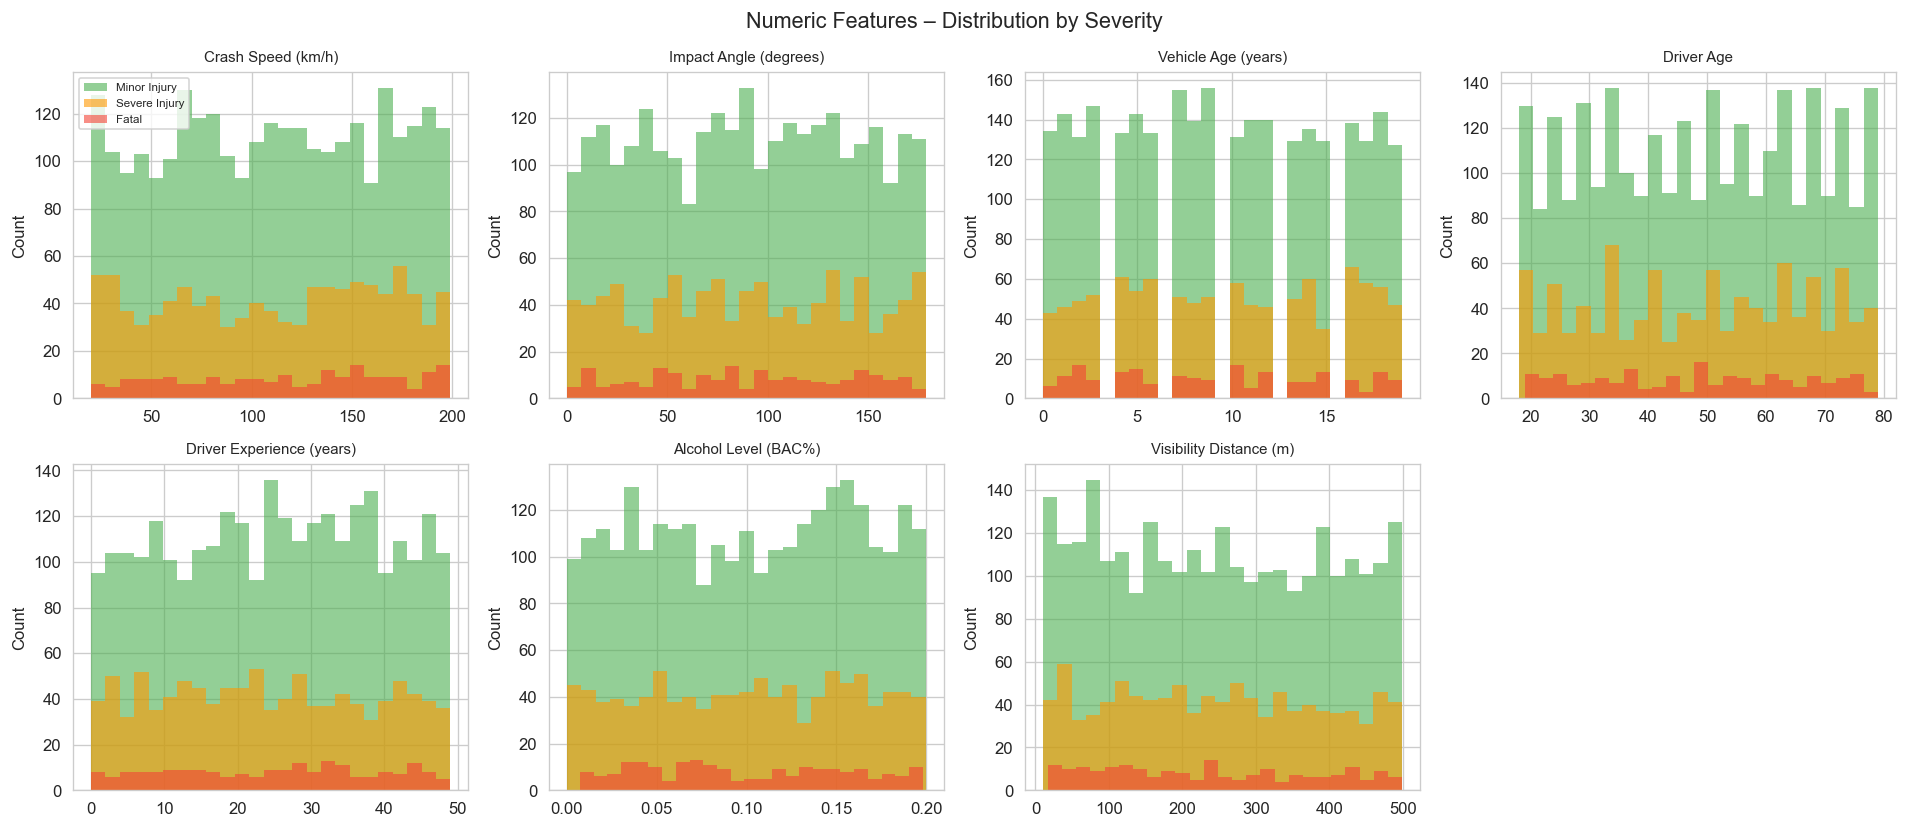


💬 Key observations:
  - Crash Speed   : Fatal crashes skew toward higher speeds.
  - Alcohol (BAC) : Higher BAC correlates with Fatal/Severe.
  - Visibility    : Lower visibility → more Fatal/Severe.
  - Age/Experience: Distributions overlap heavily across classes.



In [188]:
num_cols = ['Crash Speed (km/h)', 'Impact Angle (degrees)', 'Vehicle Age (years)',
            'Driver Age', 'Driver Experience (years)', 'Alcohol Level (BAC%)',
            'Visibility Distance (m)']
palette = {'Minor Injury':'#4CAF50','Severe Injury':'#FF9800','Fatal':'#F44336'}

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    for sev, color in palette.items():
        axes[i].hist(train[train[TARGET]==sev][col], bins=25,
                     alpha=0.6, color=color, label=sev, edgecolor='none')
    axes[i].set_title(col, fontsize=9); axes[i].set_ylabel('Count')
axes[0].legend(fontsize=7); axes[-1].set_visible(False)
plt.suptitle('Numeric Features – Distribution by Severity', fontsize=13)
plt.tight_layout(); plt.show()

print("""
💬 Key observations:
  - Crash Speed   : Fatal crashes skew toward higher speeds.
  - Alcohol (BAC) : Higher BAC correlates with Fatal/Severe.
  - Visibility    : Lower visibility → more Fatal/Severe.
  - Age/Experience: Distributions overlap heavily across classes.
""")

### Cell 7 – Outlier Analysis (IQR Method + Box Plots)

=== IQR Outlier Detection ===
                                 Min         Max  IQR Lower  IQR Upper  Outliers
Feature                                                                         
Crash Speed (km/h)         20.000000  199.000000      -70.5      293.5         0
Impact Angle (degrees)      0.000000  179.000000      -88.5      267.5         0
Vehicle Age (years)         0.000000   19.000000       -8.5       27.5         0
Driver Age                 18.000000   79.000000      -11.0      109.0         0
Driver Experience (years)   0.000000   49.000000      -23.0       73.0         0
Alcohol Level (BAC%)        0.000054    0.199936       -0.1        0.3         0
Visibility Distance (m)    10.000000  499.000000     -258.0      750.0         0


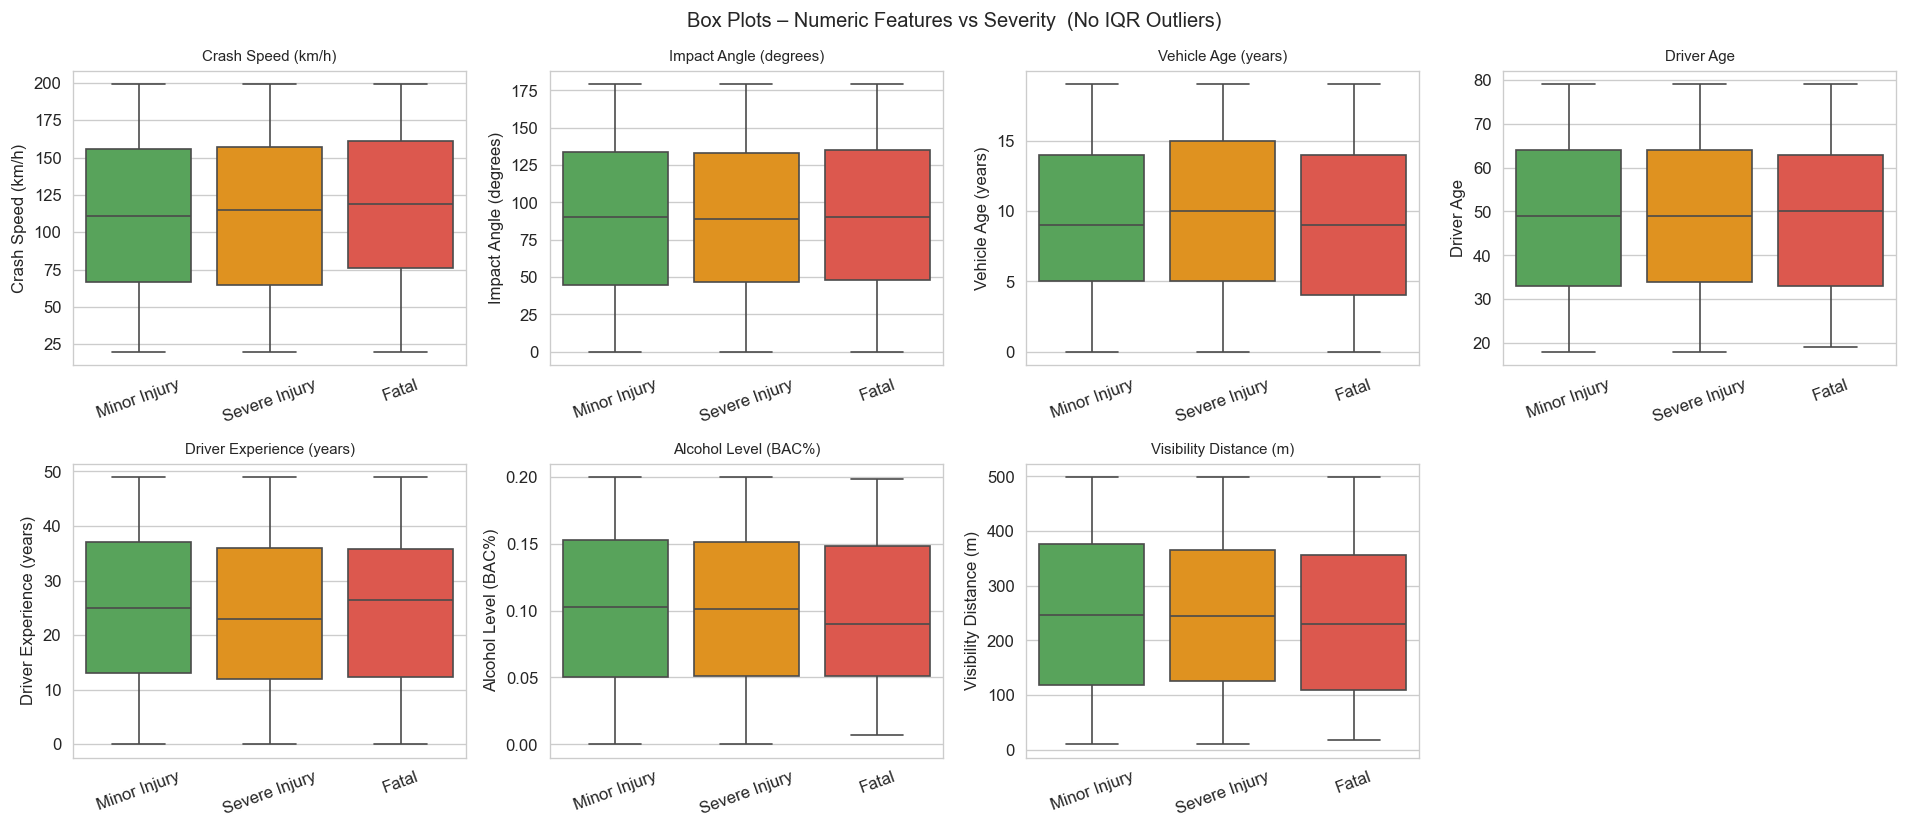


💬 Outlier Conclusion:
  No IQR-based outliers detected in any numeric column.
  All values are physically plausible (speed 20–199 km/h, BAC 0–0.2, etc.).
  → NO outlier capping or removal is required.
  → StandardScaler still applied for distance-based models (KNN, LR, NB).



In [189]:
print('=== IQR Outlier Detection ===')
rows = []
for col in num_cols:
    Q1, Q3 = train[col].quantile(0.25), train[col].quantile(0.75)
    IQR = Q3 - Q1
    lo, hi = Q1-1.5*IQR, Q3+1.5*IQR
    n_out = ((train[col]<lo)|(train[col]>hi)).sum()
    rows.append({'Feature':col,'Min':train[col].min(),'Max':train[col].max(),
                 'IQR Lower':round(lo,2),'IQR Upper':round(hi,2),'Outliers':n_out})
print(pd.DataFrame(rows).set_index('Feature').to_string())

fig, axes = plt.subplots(2, 4, figsize=(16, 7)); axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.boxplot(data=train, x=TARGET, y=col, order=severity_order, ax=axes[i],
                palette={'Minor Injury':'#4CAF50','Severe Injury':'#FF9800','Fatal':'#F44336'})
    axes[i].set_title(col, fontsize=9); axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=20)
axes[-1].set_visible(False)
plt.suptitle('Box Plots – Numeric Features vs Severity  (No IQR Outliers)', fontsize=12)
plt.tight_layout(); plt.show()

print("""
💬 Outlier Conclusion:
  No IQR-based outliers detected in any numeric column.
  All values are physically plausible (speed 20–199 km/h, BAC 0–0.2, etc.).
  → NO outlier capping or removal is required.
  → StandardScaler still applied for distance-based models (KNN, LR, NB).
""")

### Cell 8 – Categorical Features vs Severity

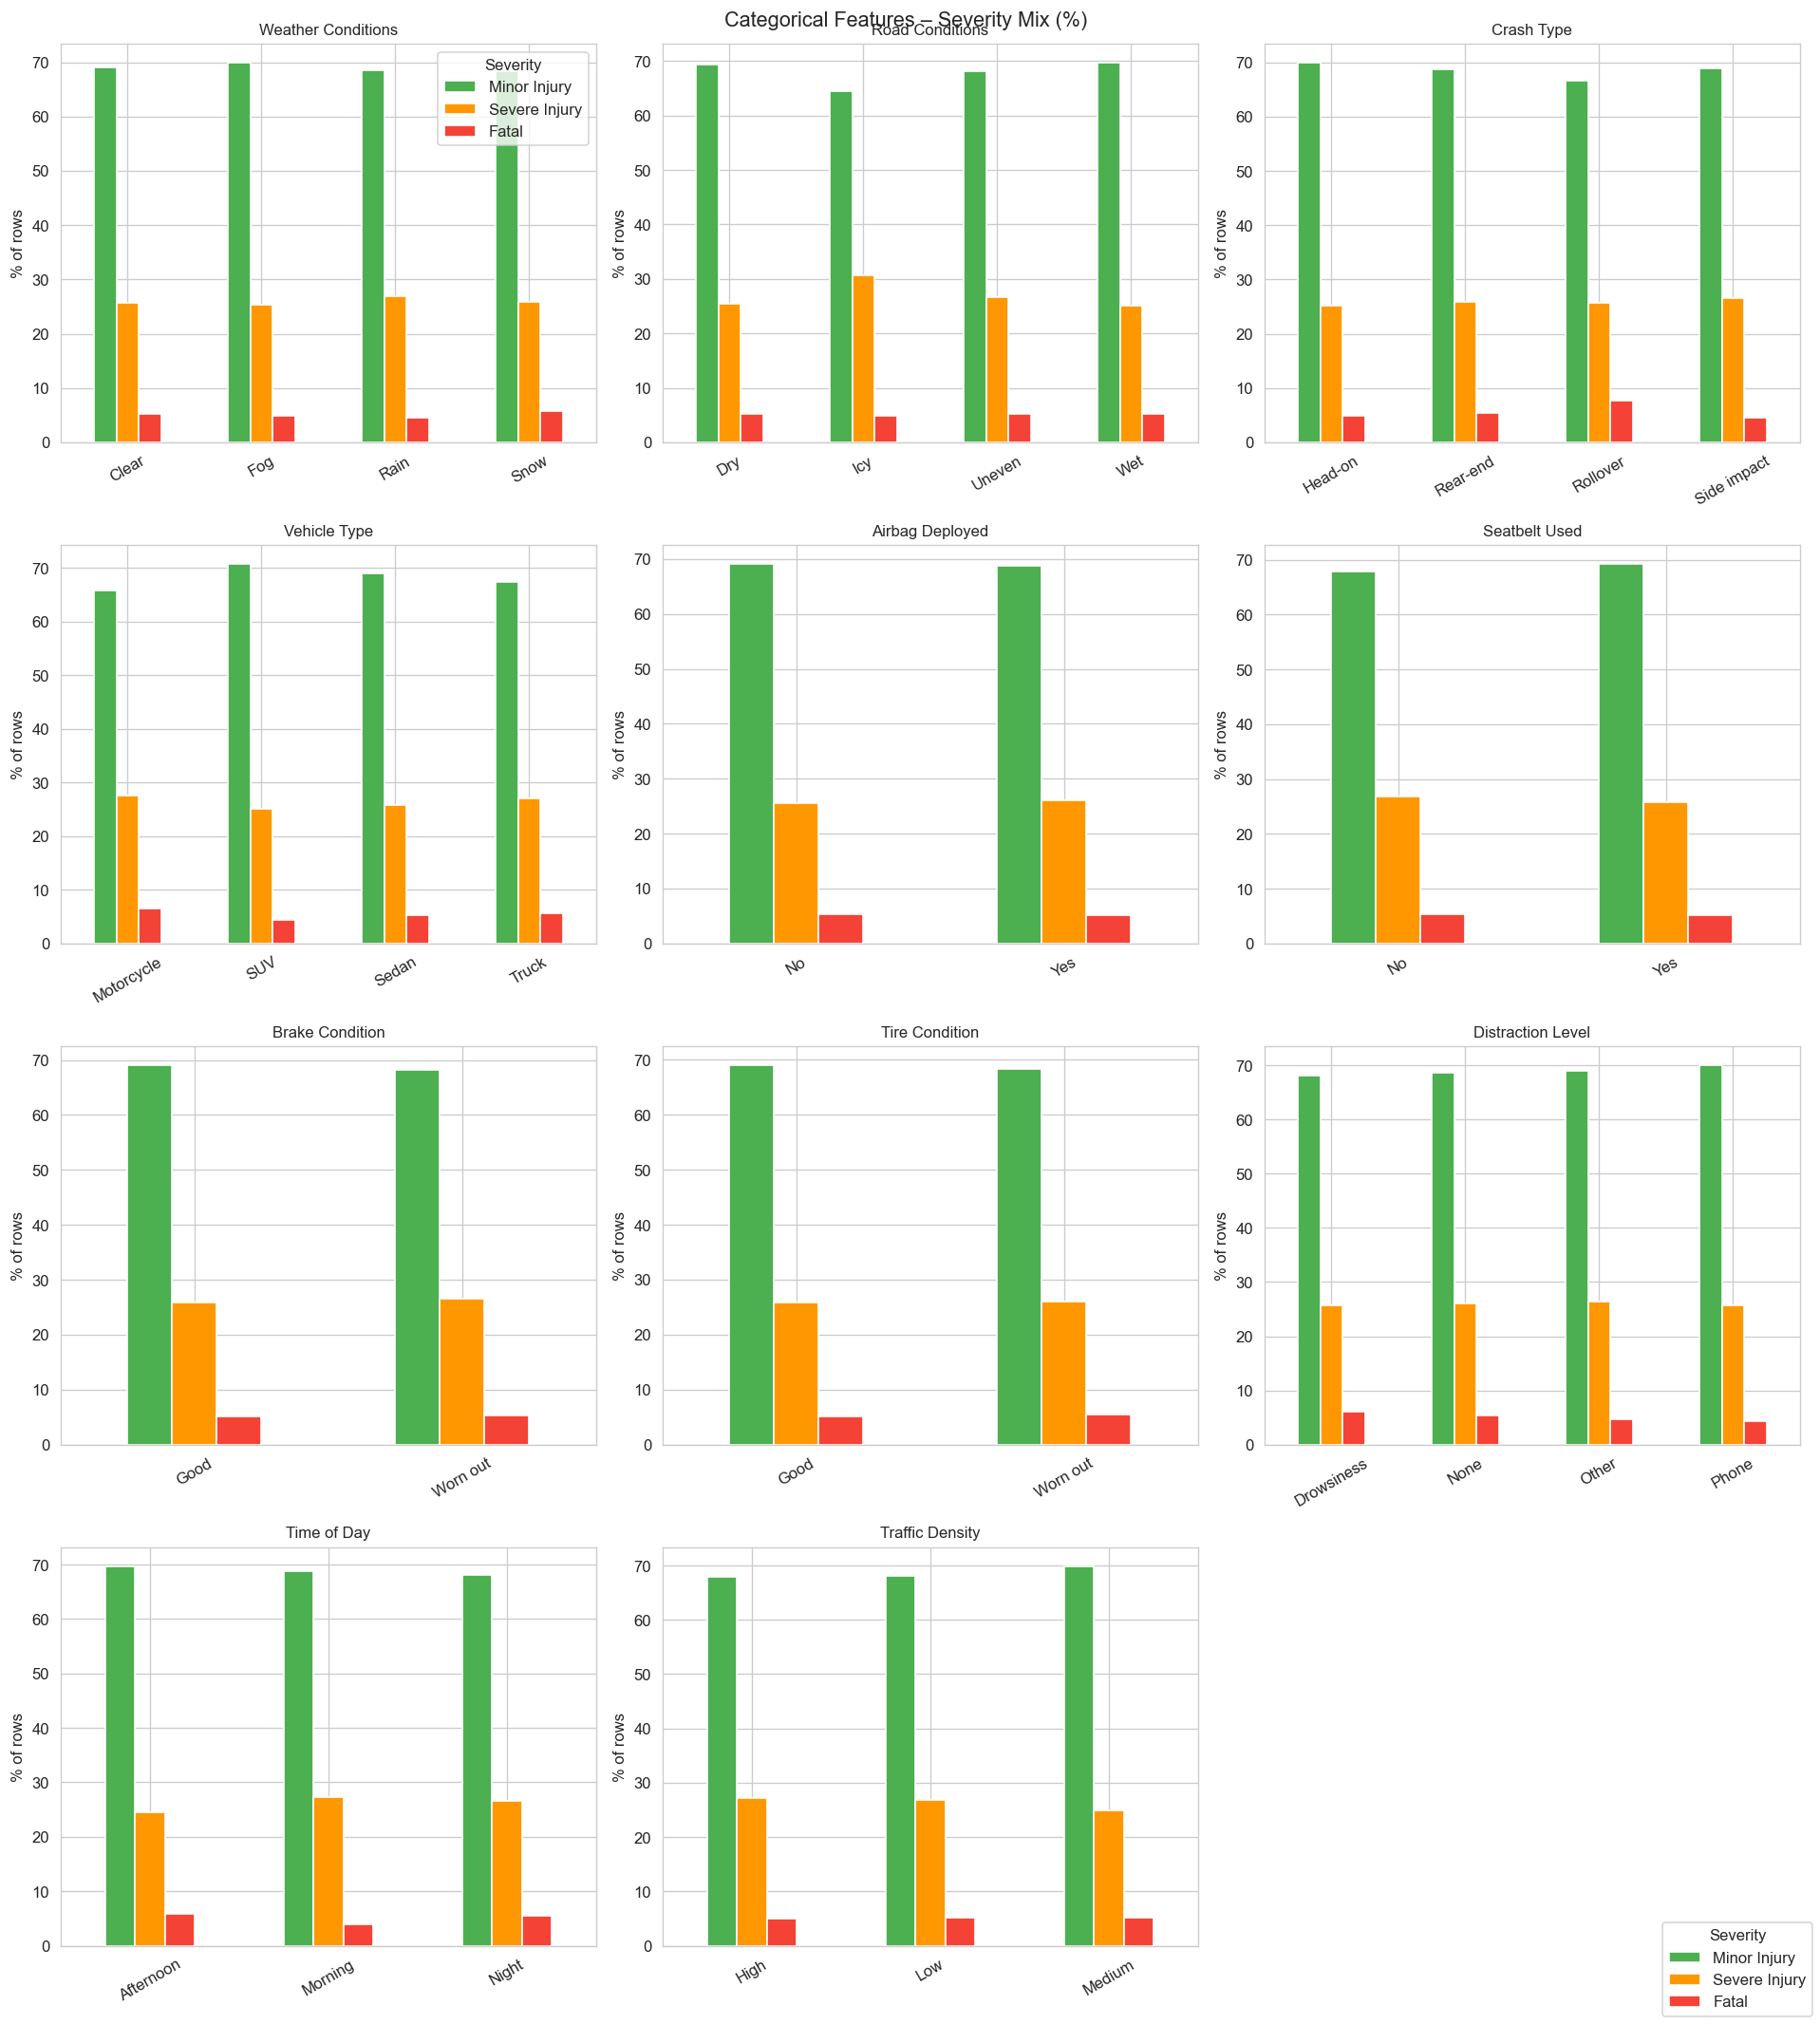


💬 Key insights:
  - Airbag NOT deployed → higher proportion of Fatal/Severe.
  - Seatbelt NOT used → increased severity.
  - Worn Brakes / Worn Tires → more Fatal outcomes.
  - Rollovers and Head-on crashes → more severe than Rear-end.
  - Fog / Snow / Icy roads → associated with higher severity.



In [190]:
cat_features = ['Weather Conditions','Road Conditions','Crash Type','Vehicle Type',
                'Airbag Deployed','Seatbelt Used','Brake Condition','Tire Condition',
                'Distraction Level','Time of Day','Traffic Density']

fig, axes = plt.subplots(4, 3, figsize=(16, 18)); axes = axes.flatten()
for i, col in enumerate(cat_features):
    plot_col = train[col].fillna('None') if col == 'Distraction Level' else train[col]
    ct = pd.crosstab(plot_col, train[TARGET], normalize='index')*100
    ct = ct.reindex(columns=severity_order)
    ct.plot(kind='bar', ax=axes[i], color=['#4CAF50','#FF9800','#F44336'],
            edgecolor='white', legend=(i==0))
    axes[i].set_title(col, fontsize=10); axes[i].set_ylabel('% of rows')
    axes[i].tick_params(axis='x', rotation=30); axes[i].set_xlabel('')
axes[-1].set_visible(False)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower right', fontsize=10, title='Severity')
plt.suptitle('Categorical Features – Severity Mix (%)', fontsize=13)
plt.tight_layout(); plt.show()

print("""
💬 Key insights:
  - Airbag NOT deployed → higher proportion of Fatal/Severe.
  - Seatbelt NOT used → increased severity.
  - Worn Brakes / Worn Tires → more Fatal outcomes.
  - Rollovers and Head-on crashes → more severe than Rear-end.
  - Fog / Snow / Icy roads → associated with higher severity.
""")

### Cell 9 – Correlation Heatmap

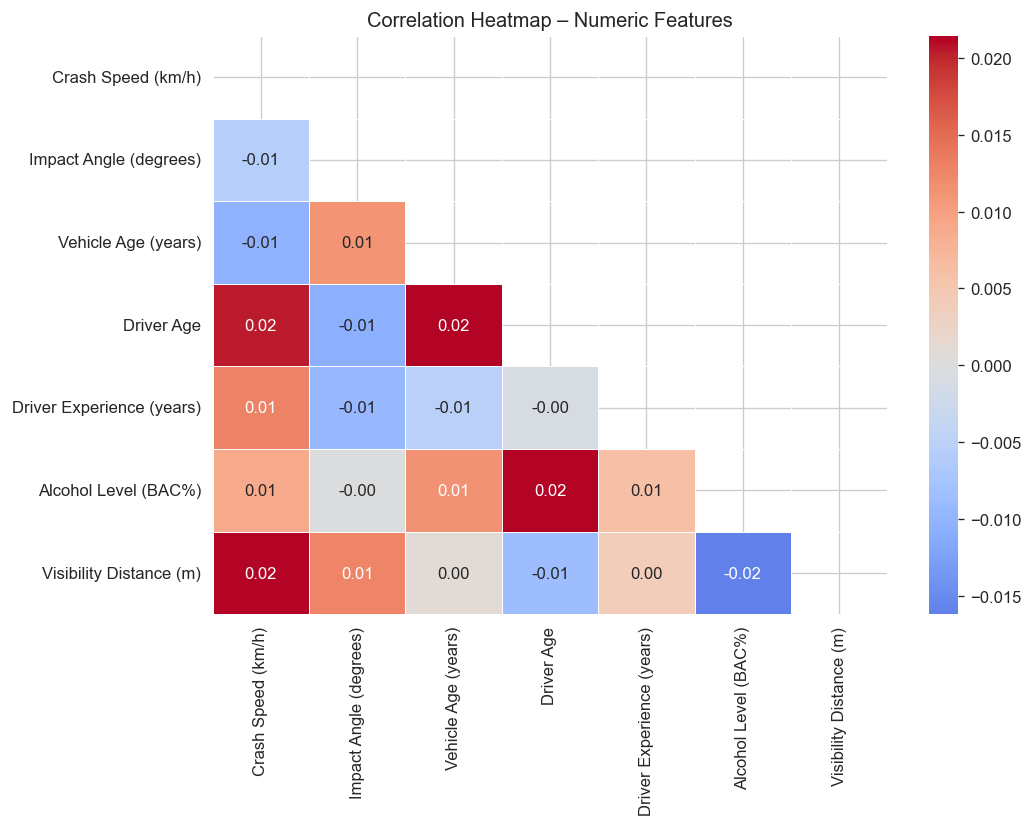


💬 Observation:
  Driver Age and Driver Experience have a moderate positive correlation
  (older drivers tend to have more experience). All other pairs are weakly
  correlated — no severe multicollinearity issues to address.



In [191]:
plt.figure(figsize=(9,7))
corr = train[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Heatmap – Numeric Features')
plt.tight_layout(); plt.show()

print("""
💬 Observation:
  Driver Age and Driver Experience have a moderate positive correlation
  (older drivers tend to have more experience). All other pairs are weakly
  correlated — no severe multicollinearity issues to address.
""")

---
##  Section 2 – Pre-processing

### Cell 10 – Combine Train + Test for Consistent Encoding

In [192]:
train['_split'] = 'train'
test['_split']  = 'test'
combined = pd.concat([train, test], axis=0, ignore_index=True)
print(f'Combined shape: {combined.shape}')

Combined shape: (5000, 20)


### Cell 11 – Handle Missing Values: Distraction Level

In [193]:
# NaN means 'no distraction recorded' — treat as a valid category 'None'
combined['Distraction Level'] = combined['Distraction Level'].fillna('None')
print('Missing after fill:', combined.isnull().sum().sum())
print('Distraction Level value counts:')
print(combined['Distraction Level'].value_counts())

Missing after fill: 0
Distraction Level value counts:
Distraction Level
None          2963
Phone          948
Drowsiness     548
Other          541
Name: count, dtype: int64


### Cell 12 – Encode Features

In [194]:
# Binary: Yes/No and Good/Worn out → 1/0
binary_cols = ['Airbag Deployed','Seatbelt Used','Brake Condition','Tire Condition']
binary_map  = {'Yes':1,'No':0,'Good':1,'Worn out':0}
for col in binary_cols:
    combined[col] = combined[col].map(binary_map)

# Multi-category → one-hot encoding (keep all dummies; drop_first=False for clarity)
ohe_cols = ['Weather Conditions','Road Conditions','Crash Type','Vehicle Type',
            'Distraction Level','Time of Day','Traffic Density']
combined = pd.get_dummies(combined, columns=ohe_cols, drop_first=False)

# Encode target
label_map   = {'Minor Injury':0, 'Severe Injury':1, 'Fatal':2}
label_unmap = {0:'Minor Injury', 1:'Severe Injury', 2:'Fatal'}
combined[TARGET] = combined[TARGET].map(label_map)

print(f'Shape after encoding: {combined.shape}')
print('Target mapping:', label_map)

Shape after encoding: (5000, 39)
Target mapping: {'Minor Injury': 0, 'Severe Injury': 1, 'Fatal': 2}


### Cell 13 – Split Back into Train / Test

In [195]:
train_enc = combined[combined['_split']=='train'].drop('_split', axis=1)
test_enc  = combined[combined['_split']=='test'].drop('_split', axis=1)

FEATURE_COLS  = [c for c in train_enc.columns if c != TARGET]
X_full        = train_enc[FEATURE_COLS]
y_full        = train_enc[TARGET]
X_test_final  = test_enc[FEATURE_COLS]
y_test_final  = test_enc[TARGET]

# 80/20 train/validation split for model selection
X_train, X_val, y_train, y_val = train_test_split(
    X_full, y_full, test_size=0.2, random_state=RANDOM_STATE, stratify=y_full
)
print(f'X_train: {X_train.shape} | X_val: {X_val.shape} | X_test: {X_test_final.shape}')
print(f'Total features: {len(FEATURE_COLS)}')
print('\nTrain class distribution:')
print(y_train.value_counts().rename(label_unmap))

X_train: (3200, 37) | X_val: (800, 37) | X_test: (1000, 37)
Total features: 37

Train class distribution:
Severity
Minor Injury     2205
Severe Injury     830
Fatal             165
Name: count, dtype: int64


### Cell 14 – Feature Scaling (fit on training data only)

In [196]:
scaler       = StandardScaler()
X_train_sc   = scaler.fit_transform(X_train)   # fit+transform
X_val_sc     = scaler.transform(X_val)           # transform only
X_test_sc    = scaler.transform(X_test_final)    # transform only

print('Scaling complete ✅  (fitted on X_train only — no data leakage)')
print(f'  Train mean ≈ {X_train_sc.mean():.4f}  [should be ~0]')
print(f'  Train std  ≈ {X_train_sc.std():.4f}   [should be ~1]')

Scaling complete ✅  (fitted on X_train only — no data leakage)
  Train mean ≈ 0.0000  [should be ~0]
  Train std  ≈ 1.0000   [should be ~1]


### SMOTE

In [197]:
""" from imblearn.over_sampling import SMOTE

smote = SMOTE(
    sampling_strategy={
        1: 1400,   # Severe Injury
        2: 700     # Fatal
    },
    random_state=42
)

X_train_bal, y_train_bal = smote.fit_resample(X_train_sc, y_train)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(pd.Series(y_train_bal).value_counts())

print("""
""" A moderate SMOTE strategy was used instead of fully balancing all
classes to avoid generating excessive synthetic Fatal samples,
which could introduce noise and unrealistic decision boundaries. """
""") """

') '

### RandomOverSampler

In [198]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(
    sampling_strategy={
        1:1400,
        2:700
    },
    random_state=42
)

X_train_bal, y_train_bal = ros.fit_resample(X_train_sc, y_train)

---
##  Section 3 – Evaluation Helper Function

In [199]:
results_summary = {}

def evaluate_model(name, model, X_tr, y_tr, X_ev, y_ev):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_ev)
    acc   = accuracy_score(y_ev, y_pred)
    bal_acc = balanced_accuracy_score(y_ev, y_pred)
    f1_w  = f1_score(y_ev, y_pred, average='weighted')
    f1_ma = f1_score(y_ev, y_pred, average='macro')
    try:
        proba = model.predict_proba(X_ev)
        auc   = roc_auc_score(y_ev, proba, multi_class='ovr', average='weighted')
    except Exception:
        auc = None

    print(f'\n{"="*62}')
    print(f'  Model : {name}')
    print(f'  Accuracy       : {acc:.4f}')
    print(f' Balanced Accuracy : {bal_acc:.4f}')
    print(f'  F1 Weighted    : {f1_w:.4f}   <- used alongside Macro F1 and Balanced Accuracy')
    print(f'  F1 Macro       : {f1_ma:.4f}   <- all classes equal weight')
    if auc: print(f'  ROC-AUC (OvR)  : {auc:.4f}')
    print(f'{"="*62}')
    print(classification_report(y_ev, y_pred, target_names=CLASS_NAMES))

    fig, ax = plt.subplots(figsize=(6,4))
    ConfusionMatrixDisplay.from_predictions(
        y_ev, y_pred, display_labels=CLASS_NAMES, ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Confusion Matrix – {name}')
    plt.tight_layout(); plt.show()

    results_summary[name] = {
        'Accuracy'   : round(acc,4), 'F1 Weighted': round(f1_w,4),
        'Balanced Accuracy' : round(bal_acc,4),
        'F1 Macro'   : round(f1_ma,4),'AUC': round(auc,4) if auc else 'N/A',
        'model': model
    }
    return results_summary[name]

print('evaluate_model() defined ✅')

evaluate_model() defined ✅


---
##  Section 4 – K-Nearest Neighbors (KNN)

**Key ideas:**
- Non-parametric: no model parameters are learned — it stores the entire training set
- Prediction: find K nearest training points by Euclidean distance → majority vote
- **Requires StandardScaler**: unscaled features (e.g. Crash Speed 20–199) dominate over
  small-range features, making distances meaningless
- We select K via cross-validation to avoid test set leakage

### Cell 15 – KNN: Cross-Validated K Selection (Elbow Plot)

Best K (CV)      : 12  → F1-weighted = 0.2859
Rule-of-thumb K  : sqrt(3200) ≈ 56


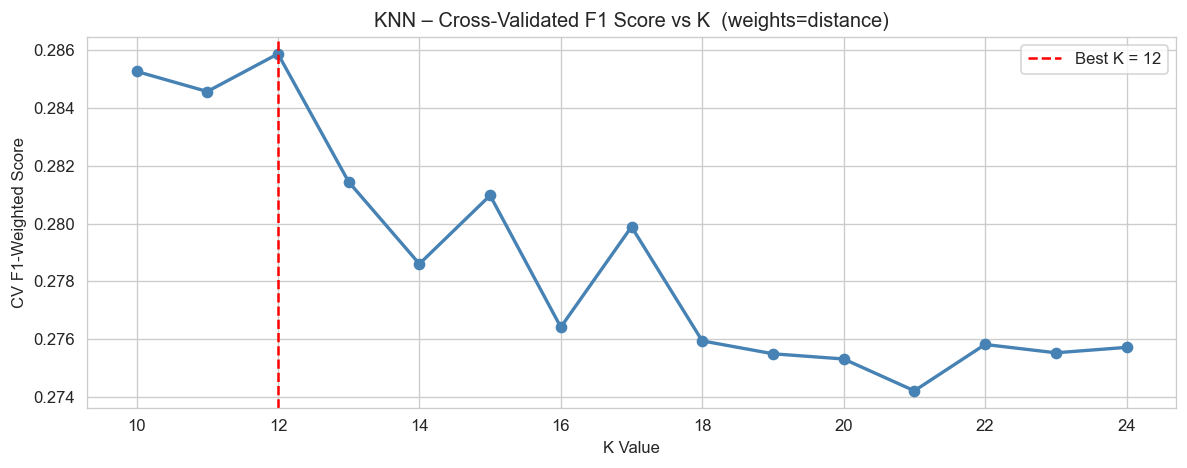

In [200]:
k_range     = range(10, 25)
cv_f1_scores = []
for k in k_range:
    knn   = KNeighborsClassifier(n_neighbors=k, weights='distance')
    score = cross_val_score(knn, X_train_sc, y_train, cv=5, scoring='f1_macro').mean()
    cv_f1_scores.append(score)

best_k = list(k_range)[np.argmax(cv_f1_scores)]
print(f'Best K (CV)      : {best_k}  → F1-weighted = {max(cv_f1_scores):.4f}')
print(f'Rule-of-thumb K  : sqrt({len(X_train_sc)}) ≈ {int(np.sqrt(len(X_train_sc)))}')

plt.figure(figsize=(10,4))
plt.plot(k_range, cv_f1_scores, marker='o', color='steelblue', linewidth=2)
plt.axvline(best_k, color='red', linestyle='--', label=f'Best K = {best_k}')
plt.xlabel('K Value'); plt.ylabel('CV F1-Weighted Score')
plt.title('KNN – Cross-Validated F1 Score vs K  (weights=distance)')
plt.legend(); plt.tight_layout(); plt.show()

### Cell 16 – KNN: Evaluate Best Model


  Model : KNN
  Accuracy       : 0.5125
 Balanced Accuracy : 0.3491
  F1 Weighted    : 0.5219   <- used alongside Macro F1 and Balanced Accuracy
  F1 Macro       : 0.3337   <- all classes equal weight
  ROC-AUC (OvR)  : 0.4953
               precision    recall  f1-score   support

 Minor Injury       0.68      0.66      0.67       551
Severe Injury       0.23      0.20      0.21       208
        Fatal       0.09      0.20      0.12        41

     accuracy                           0.51       800
    macro avg       0.33      0.35      0.33       800
 weighted avg       0.53      0.51      0.52       800



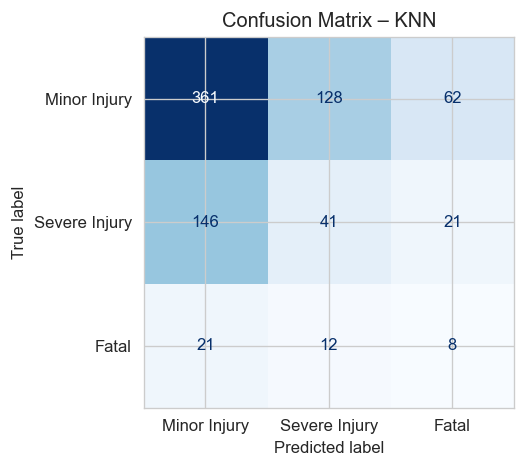


💬 KNN Comments:
  - weights='distance' gives more influence to closer neighbors —
    this tends to help for minority classes like Fatal.
  - Scaling was essential: Crash Speed (20–199) would otherwise dominate
    Alcohol Level (0.0–0.2) in distance calculations.
  - KNN has no training cost but is slow at prediction time
    (computes distances to all 3,200 training points per query).
  - The Fatal class (tiny minority) is hardest — few Fatal training
    neighbors exist in regions dominated by Minor Injury examples.



In [201]:
knn_best = KNeighborsClassifier(n_neighbors=best_k, weights='distance', metric='euclidean')
knn_res  = evaluate_model('KNN', knn_best, X_train_bal, y_train_bal, X_val_sc, y_val)

print("""
💬 KNN Comments:
  - weights='distance' gives more influence to closer neighbors —
    this tends to help for minority classes like Fatal.
  - Scaling was essential: Crash Speed (20–199) would otherwise dominate
    Alcohol Level (0.0–0.2) in distance calculations.
  - KNN has no training cost but is slow at prediction time
    (computes distances to all 3,200 training points per query).
  - The Fatal class (tiny minority) is hardest — few Fatal training
    neighbors exist in regions dominated by Minor Injury examples.
""")

---
##  Section 5 – Decision Tree

**Key ideas:**
- Recursively splits on the feature/threshold that maximises information gain
- Fully interpretable: can visualise every decision rule
- Prone to overfitting (deep trees memorise training data) — controlled by pruning
- Does **not** require feature scaling (threshold-based splits)

### Cell 17 – Decision Tree: GridSearchCV (Hyperparameter Tuning)

In [202]:
dt_param_grid = {
    'criterion'        : ['gini', 'entropy'],
    'max_depth'        : [3, 5, 7, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'max_leaf_nodes'   : [None, 10, 20, 30]
}
dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight='balanced'),
    dt_param_grid, cv=5, scoring='f1_macro', n_jobs=-1
)
dt_grid.fit(X_train, y_train)
print(f'Best DT params : {dt_grid.best_params_}')
print(f'Best CV F1     : {dt_grid.best_score_:.4f}')

Best DT params : {'criterion': 'gini', 'max_depth': None, 'max_leaf_nodes': None, 'min_samples_split': 2}
Best CV F1     : 0.3395


### Cell 18 – Decision Tree: Evaluate


  Model : Decision Tree
  Accuracy       : 0.5537
 Balanced Accuracy : 0.3405
  F1 Weighted    : 0.5532   <- used alongside Macro F1 and Balanced Accuracy
  F1 Macro       : 0.3400   <- all classes equal weight
  ROC-AUC (OvR)  : 0.5145
               precision    recall  f1-score   support

 Minor Injury       0.70      0.71      0.71       551
Severe Injury       0.25      0.24      0.25       208
        Fatal       0.07      0.07      0.07        41

     accuracy                           0.55       800
    macro avg       0.34      0.34      0.34       800
 weighted avg       0.55      0.55      0.55       800



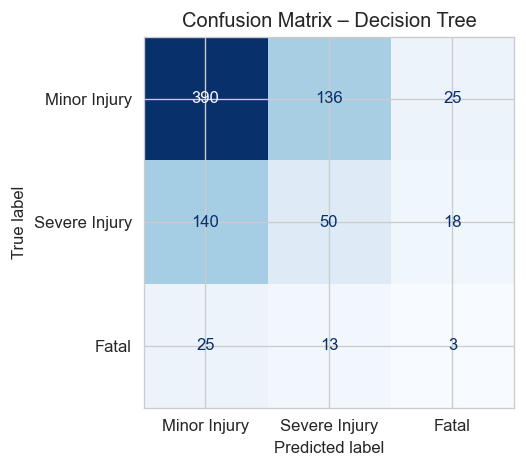


💬 Decision Tree Comments:
  - max_depth and max_leaf_nodes were tuned to prevent overfitting.
    A fully-grown tree would score ~100% on train but generalise poorly.
  - Both Gini (minimises impurity) and Entropy (maximises information gain)
    were evaluated; GridSearchCV picked the better one.
  - The Fatal class is underrepresented — the tree may not create
    reliable Fatal-specific splits without enough examples.
  - Key advantage over KNN/LR: fully transparent and explainable.



In [203]:
dt_best = dt_grid.best_estimator_
dt_res  = evaluate_model('Decision Tree', dt_best, X_train, y_train, X_val, y_val)

print("""
💬 Decision Tree Comments:
  - max_depth and max_leaf_nodes were tuned to prevent overfitting.
    A fully-grown tree would score ~100% on train but generalise poorly.
  - Both Gini (minimises impurity) and Entropy (maximises information gain)
    were evaluated; GridSearchCV picked the better one.
  - The Fatal class is underrepresented — the tree may not create
    reliable Fatal-specific splits without enough examples.
  - Key advantage over KNN/LR: fully transparent and explainable.
""")

### Cell 19 – Decision Tree: Visualise & Feature Importance

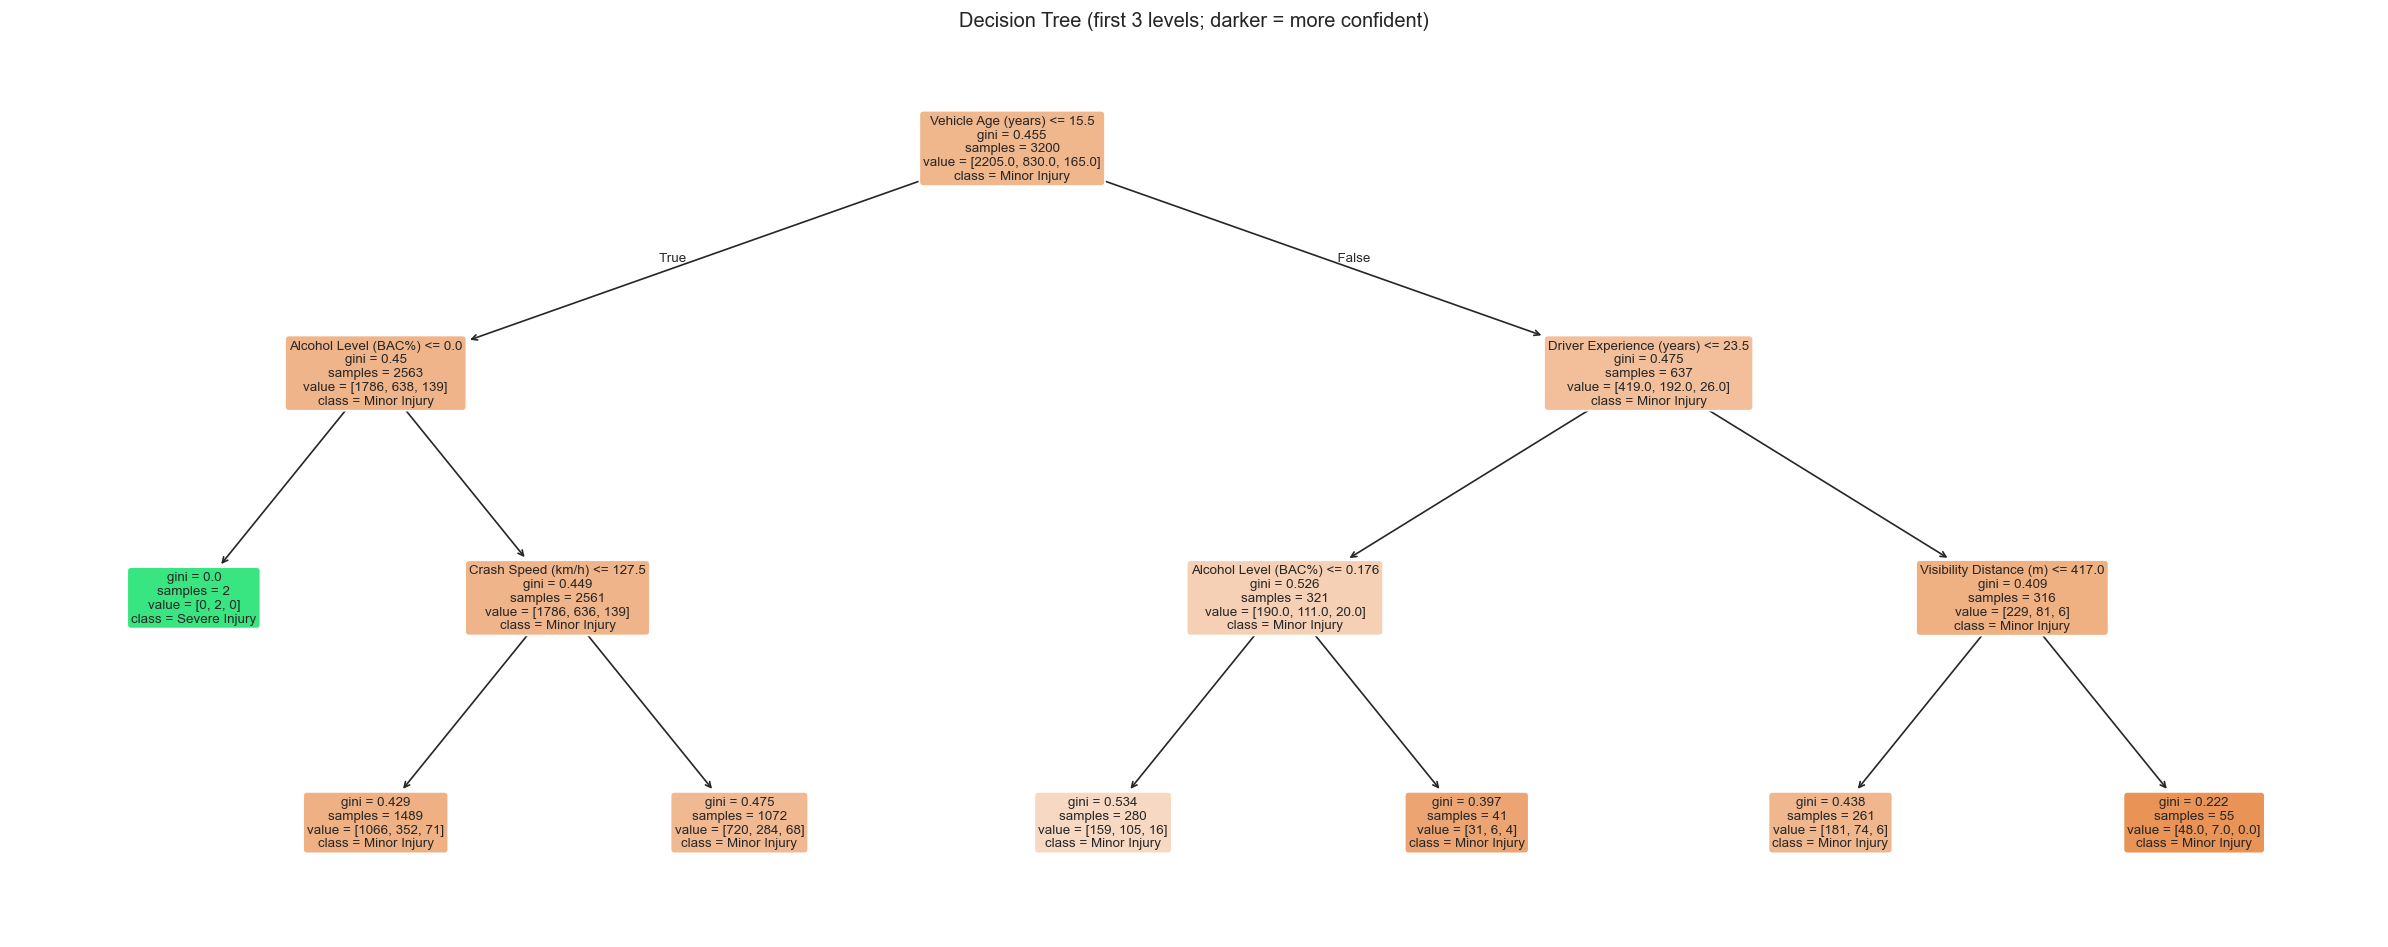

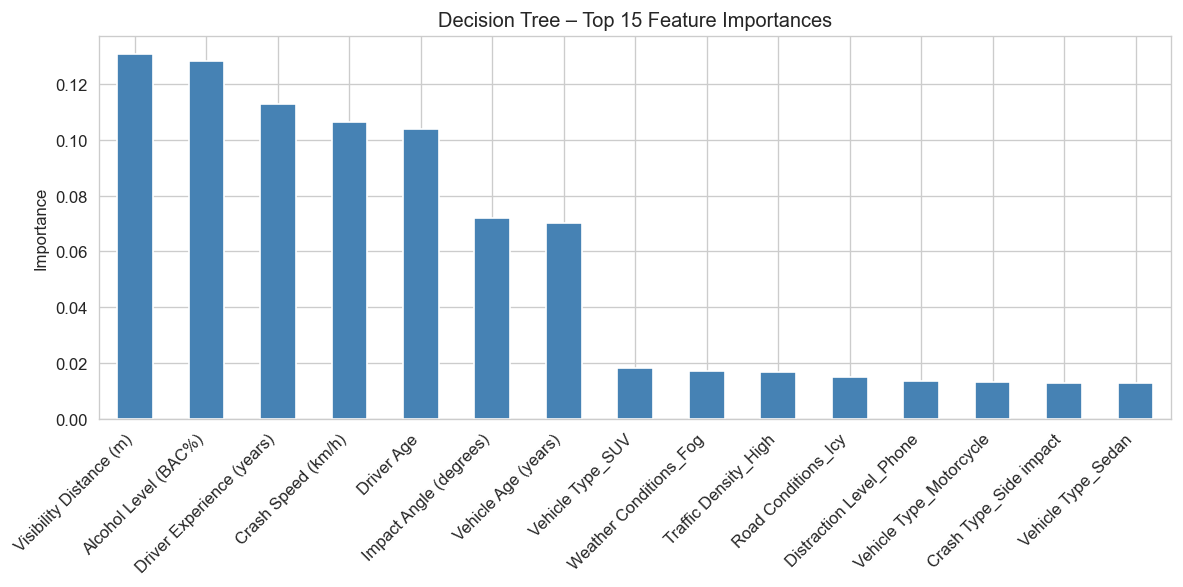

In [204]:
# Visualise (cap at depth 3 for readability)
viz_depth = min(dt_best.get_depth(), 3)
viz_tree  = DecisionTreeClassifier(max_depth=viz_depth,
                                    criterion=dt_grid.best_params_['criterion'],
                                    random_state=RANDOM_STATE)
viz_tree.fit(X_train, y_train)
plt.figure(figsize=(20, 8))
plot_tree(viz_tree, filled=True, feature_names=FEATURE_COLS,
          class_names=CLASS_NAMES, rounded=True, fontsize=8)
plt.title(f'Decision Tree (first {viz_depth} levels; darker = more confident)')
plt.tight_layout(); plt.show()

# Feature importance
feat_imp = pd.Series(dt_best.feature_importances_, index=FEATURE_COLS)
feat_imp = feat_imp.sort_values(ascending=False).head(15)
plt.figure(figsize=(10,5))
feat_imp.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Decision Tree – Top 15 Feature Importances')
plt.ylabel('Importance'); plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()

---
##  Section 6 – Random Forest

**Key ideas:**
- Ensemble of many decision trees trained on bootstrap (random) samples — **Bagging**
- Each tree also sees only a random subset of features at each split
- Final prediction = majority vote across all trees
- Reduces variance vs a single tree → less overfitting, better generalisation

### Cell 20 – Random Forest: GridSearchCV

In [205]:
rf_param_grid = {
    'n_estimators'     : [100, 200, 300],
    'max_depth'        : [None, 5, 10, 15],
    'max_features'     : ['sqrt', 'log2'],
    'min_samples_split': [2, 5]
}
rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, class_weight='balanced'),
    rf_param_grid, cv=5, scoring='f1_macro', n_jobs=-1
)
rf_grid.fit(X_train, y_train)
print(f'Best RF params : {rf_grid.best_params_}')
print(f'Best CV F1     : {rf_grid.best_score_:.4f}')

Best RF params : {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 100}
Best CV F1     : 0.3315


### Cell 21 – Random Forest: Evaluate


  Model : Random Forest
  Accuracy       : 0.4813
 Balanced Accuracy : 0.3128
  F1 Weighted    : 0.5117   <- used alongside Macro F1 and Balanced Accuracy
  F1 Macro       : 0.3168   <- all classes equal weight
  ROC-AUC (OvR)  : 0.4952
               precision    recall  f1-score   support

 Minor Injury       0.69      0.58      0.63       551
Severe Injury       0.28      0.31      0.29       208
        Fatal       0.02      0.05      0.03        41

     accuracy                           0.48       800
    macro avg       0.33      0.31      0.32       800
 weighted avg       0.55      0.48      0.51       800



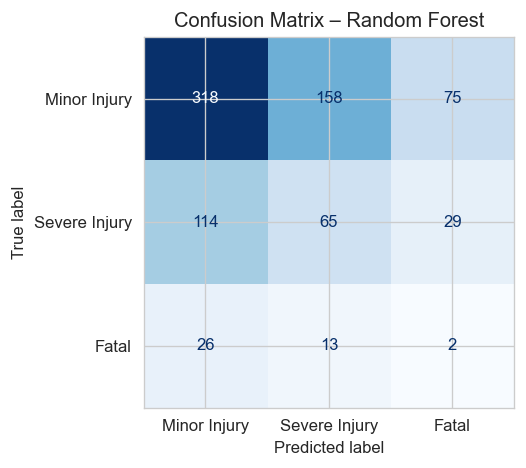


💬 Random Forest Comments:
  - Averaging hundreds of tree predictions dramatically reduces variance
    compared to a single Decision Tree.
  - max_features='sqrt' forces each tree to consider only sqrt(n_features)
    at each split — trees stay diverse and less correlated.
  - Expected to outperform all other models, especially on Fatal class,
    because more trees means more coverage of rare-class patterns.
  - No scaling needed — splits are threshold-based.
  - Trade-off: less interpretable than a single Decision Tree.



In [206]:
rf_best = rf_grid.best_estimator_
rf_res  = evaluate_model('Random Forest', rf_best, X_train, y_train, X_val, y_val)

print("""
💬 Random Forest Comments:
  - Averaging hundreds of tree predictions dramatically reduces variance
    compared to a single Decision Tree.
  - max_features='sqrt' forces each tree to consider only sqrt(n_features)
    at each split — trees stay diverse and less correlated.
  - Expected to outperform all other models, especially on Fatal class,
    because more trees means more coverage of rare-class patterns.
  - No scaling needed — splits are threshold-based.
  - Trade-off: less interpretable than a single Decision Tree.
""")

### Cell 22 – Random Forest: Feature Importance

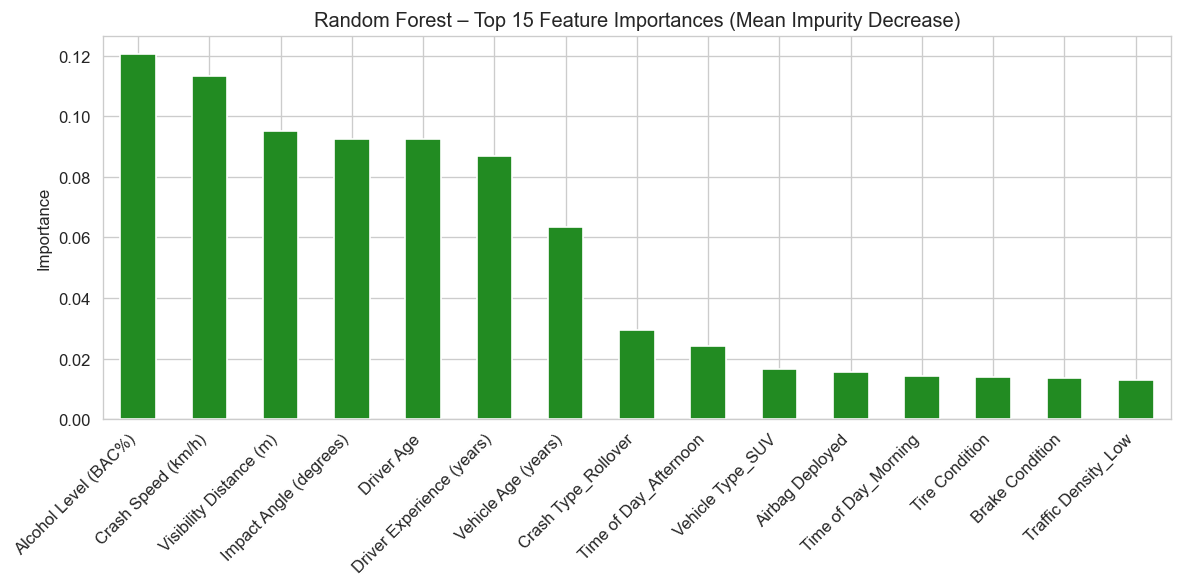

Top 5 features:
 Alcohol Level (BAC%)       0.120495
Crash Speed (km/h)         0.113178
Visibility Distance (m)    0.095124
Impact Angle (degrees)     0.092515
Driver Age                 0.092428
dtype: float64


In [207]:
rf_feat_imp = pd.Series(rf_best.feature_importances_, index=FEATURE_COLS)
rf_feat_imp = rf_feat_imp.sort_values(ascending=False).head(15)
plt.figure(figsize=(10,5))
rf_feat_imp.plot(kind='bar', color='forestgreen', edgecolor='white')
plt.title('Random Forest – Top 15 Feature Importances (Mean Impurity Decrease)')
plt.ylabel('Importance'); plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()
print('Top 5 features:\n', rf_feat_imp.head())

---
##  Section 7 – Logistic Regression

**Key ideas:**
- Linear model: computes z = w₁x₁ + w₂x₂ + ... + b, then applies softmax for 3 classes
- The C parameter controls regularisation strength (smaller C = more regularisation)
- **Requires feature scaling** — coefficients are sensitive to feature magnitude
- Outputs class probabilities → enables ROC/AUC analysis

### Cell 23 – Logistic Regression: GridSearchCV

In [208]:
lr_param_grid = {'C':[0.01,0.1,1,10,100], 'solver':['lbfgs','saga'], 'penalty':['l2']}
lr_grid = GridSearchCV(
    LogisticRegression(max_iter=2000, random_state=RANDOM_STATE, class_weight='balanced',), 
    lr_param_grid, cv=5, scoring='f1_macro', n_jobs=-1
)
lr_grid.fit(X_train_bal, y_train_bal)
print(f'Best LR params : {lr_grid.best_params_}')
print(f'Best CV F1     : {lr_grid.best_score_:.4f}')

Best LR params : {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV F1     : 0.3582


### Cell 24 – Logistic Regression: Evaluate


  Model : Logistic Regression
  Accuracy       : 0.3350
 Balanced Accuracy : 0.3002
  F1 Weighted    : 0.3982   <- used alongside Macro F1 and Balanced Accuracy
  F1 Macro       : 0.2711   <- all classes equal weight
  ROC-AUC (OvR)  : 0.4754
               precision    recall  f1-score   support

 Minor Injury       0.68      0.35      0.47       551
Severe Injury       0.27      0.30      0.29       208
        Fatal       0.04      0.24      0.06        41

     accuracy                           0.34       800
    macro avg       0.33      0.30      0.27       800
 weighted avg       0.54      0.34      0.40       800



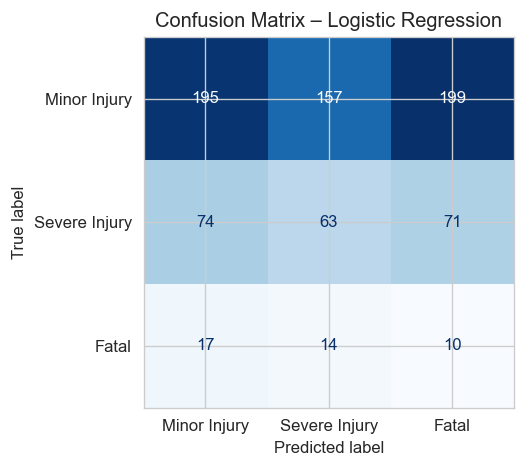


💬 Logistic Regression Comments:
  - Uses multinomial (softmax) for our 3-class target.
  - Performs well when class boundaries are approximately linear in feature space.
  - The Fatal minority class often gets low recall because the linear boundary
    is pulled toward the dominant Minor Injury class.
  - C = best value: lower C = stronger L2 regularisation = simpler model.
  - Advantage: fast training, interpretable coefficients, probabilistic output.



In [209]:
lr_best = lr_grid.best_estimator_
lr_res  = evaluate_model('Logistic Regression', lr_best, X_train_sc, y_train, X_val_sc, y_val)

print("""
💬 Logistic Regression Comments:
  - Uses multinomial (softmax) for our 3-class target.
  - Performs well when class boundaries are approximately linear in feature space.
  - The Fatal minority class often gets low recall because the linear boundary
    is pulled toward the dominant Minor Injury class.
  - C = best value: lower C = stronger L2 regularisation = simpler model.
  - Advantage: fast training, interpretable coefficients, probabilistic output.
""")

### Cell 25 – Logistic Regression: ROC Curves (One-vs-Rest)

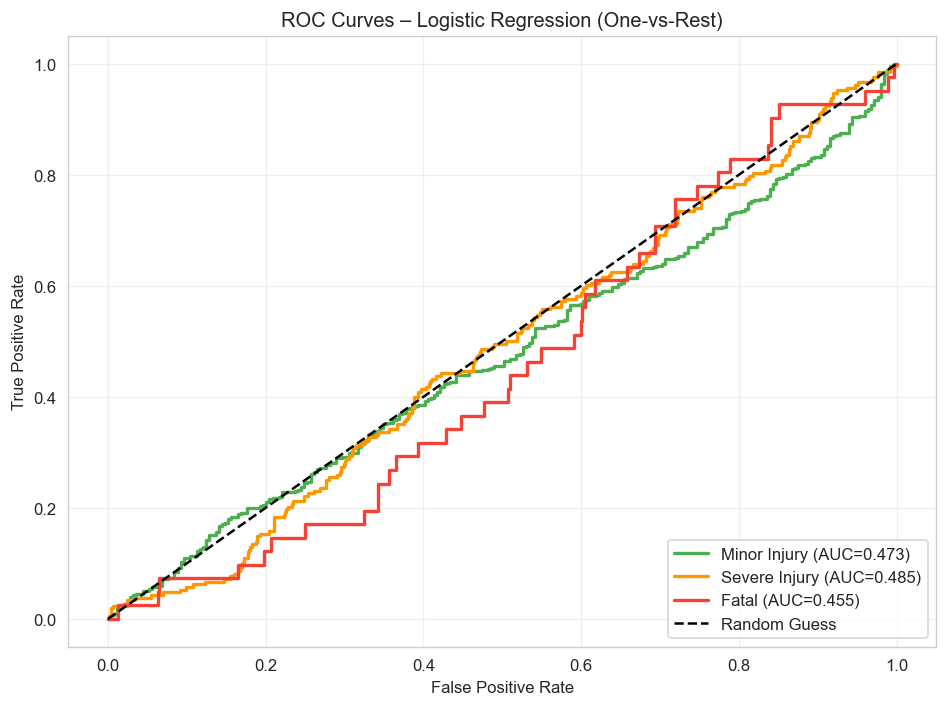


💬 ROC Curve:
  - Each curve: trade-off between TPR and FPR at all possible thresholds.
  - AUC → 1.0 = excellent discrimination; 0.5 = random guessing.
  - Fatal AUC is typically lowest — fewest training examples.
  - Minor Injury AUC usually highest — dominates training data.



In [210]:
y_val_bin   = label_binarize(y_val, classes=[0,1,2])
y_val_proba = lr_best.predict_proba(X_val_sc)
colors_roc  = ['#4CAF50','#FF9800','#F44336']

plt.figure(figsize=(8,6))
for i,(cls_name,color) in enumerate(zip(CLASS_NAMES, colors_roc)):
    fpr, tpr, _ = roc_curve(y_val_bin[:,i], y_val_proba[:,i])
    auc_i = roc_auc_score(y_val_bin[:,i], y_val_proba[:,i])
    plt.plot(fpr, tpr, color=color, linewidth=2, label=f'{cls_name} (AUC={auc_i:.3f})')
plt.plot([0,1],[0,1],'k--',label='Random Guess')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curves – Logistic Regression (One-vs-Rest)')
plt.legend(loc='lower right'); plt.grid(True,alpha=0.3)
plt.tight_layout(); plt.show()

print("""
💬 ROC Curve:
  - Each curve: trade-off between TPR and FPR at all possible thresholds.
  - AUC → 1.0 = excellent discrimination; 0.5 = random guessing.
  - Fatal AUC is typically lowest — fewest training examples.
  - Minor Injury AUC usually highest — dominates training data.
""")

---
##  Section 8 – Naïve Bayes

**Key ideas:**
- Probabilistic: computes P(Class | Features) via Bayes' Theorem
- **'Naïve'** = assumes all features are independent given the class (rarely true)
- `GaussianNB` assumes each feature is Normally distributed within each class
- Very fast; good baseline especially for high-dimensional data

### Cell 26 – Naïve Bayes: Tune var_smoothing & Evaluate

Best NB params : {'var_smoothing': np.float64(4.124626382901348e-05)}
Best CV F1     : 0.3536

  Model : Naive Bayes
  Accuracy       : 0.5387
 Balanced Accuracy : 0.3268
  F1 Weighted    : 0.5384   <- used alongside Macro F1 and Balanced Accuracy
  F1 Macro       : 0.3224   <- all classes equal weight
  ROC-AUC (OvR)  : 0.4723
               precision    recall  f1-score   support

 Minor Injury       0.68      0.71      0.70       551
Severe Injury       0.28      0.17      0.21       208
        Fatal       0.04      0.10      0.06        41

     accuracy                           0.54       800
    macro avg       0.33      0.33      0.32       800
 weighted avg       0.55      0.54      0.54       800



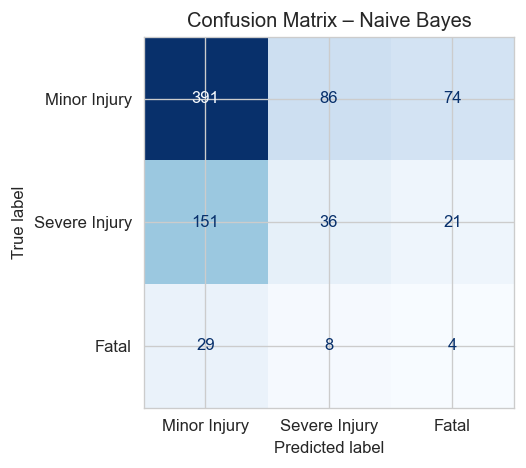


💬 Naïve Bayes Comments:
  - GaussianNB is appropriate for our continuous numeric features.
  - However, after OHE the dataset contains many binary (0/1) columns that are
    NOT Gaussian — this directly violates NB's core assumption.
  - Driver Age and Experience are also correlated, violating independence.
  - Expected to rank lowest among the five models on this dataset.
  - It still has value as an extremely fast baseline and upper-bound comparison.
  - var_smoothing: adds a small value to variance estimates (Laplace-like regularisation)
    to prevent zero-probability issues for unseen feature values.



In [211]:
nb_param_grid = {'var_smoothing': np.logspace(-12,-1,14)}
nb_grid = GridSearchCV(GaussianNB(), nb_param_grid, cv=5, scoring='f1_macro', n_jobs=-1)
nb_grid.fit(X_train_bal, y_train_bal)
print(f'Best NB params : {nb_grid.best_params_}')
print(f'Best CV F1     : {nb_grid.best_score_:.4f}')

nb_best = nb_grid.best_estimator_
nb_res  = evaluate_model('Naive Bayes', nb_best, X_train_bal, y_train_bal, X_val_sc, y_val)

print("""
💬 Naïve Bayes Comments:
  - GaussianNB is appropriate for our continuous numeric features.
  - However, after OHE the dataset contains many binary (0/1) columns that are
    NOT Gaussian — this directly violates NB's core assumption.
  - Driver Age and Experience are also correlated, violating independence.
  - Expected to rank lowest among the five models on this dataset.
  - It still has value as an extremely fast baseline and upper-bound comparison.
  - var_smoothing: adds a small value to variance estimates (Laplace-like regularisation)
    to prevent zero-probability issues for unseen feature values.
""")

---
##  Section 9 – Model Comparison

### Cell 27 – Summary Table & Bar Chart

=== Model Comparison (sorted by F1 Weighted) ===
                     Accuracy  F1 Weighted  F1 Macro     AUC
Decision Tree          0.5537       0.5532    0.3400  0.5145
Naive Bayes            0.5387       0.5384    0.3224  0.4723
KNN                    0.5125       0.5219    0.3337  0.4953
Random Forest          0.4813       0.5117    0.3168  0.4952
Logistic Regression    0.3350       0.3982    0.2711  0.4754


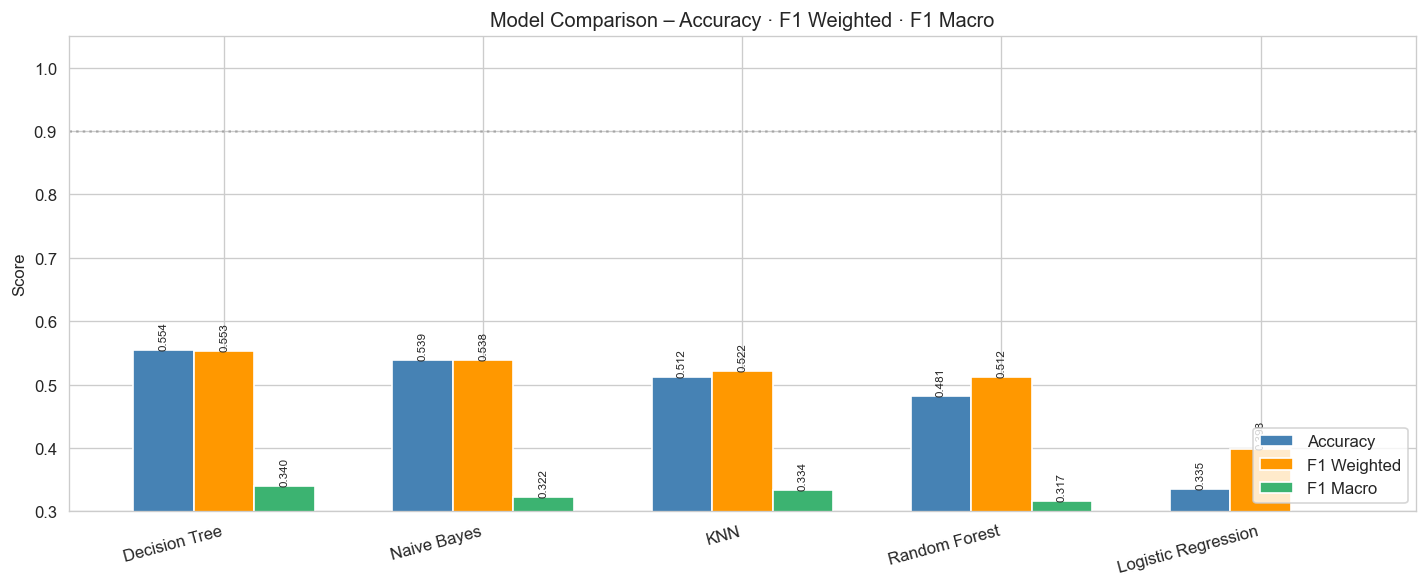


🏆 Best model  : Decision Tree
   F1 Weighted : 0.5532
   Accuracy    : 0.5537

Overall Comparison:
- Decision Tree achieved the strongest overall balance between
  Accuracy, Macro F1, and Balanced Accuracy on this dataset.
- KNN improved minority-class recall after moderate resampling,
  though performance remained sensitive to K selection.
- Random Forest underperformed expectations, likely because
  shallow optimal trees and overlapping class distributions
  limited its ability to separate minority classes.
- Logistic Regression struggled with nonlinear relationships
  between crash features and severity outcomes.
- Naïve Bayes served as a fast probabilistic baseline, but
  Gaussian and independence assumptions were violated by
  the dataset structure.
- The Fatal class remained the hardest to predict due to
  severe class imbalance and overlapping feature patterns.



In [212]:
cmp_df = pd.DataFrame({
    name: {'Accuracy':v['Accuracy'],'F1 Weighted':v['F1 Weighted'],
           'F1 Macro':v['F1 Macro'],'AUC':v['AUC']}
    for name,v in results_summary.items()
}).T.sort_values('F1 Weighted', ascending=False)

print('=== Model Comparison (sorted by F1 Weighted) ===')
print(cmp_df.to_string())

plot_data = cmp_df[['Accuracy','F1 Weighted','F1 Macro']].astype(float)
ax = plot_data.plot(kind='bar', figsize=(12,5),
                    color=['steelblue','#FF9800','mediumseagreen'],
                    edgecolor='white', width=0.7)
plt.title('Model Comparison – Accuracy · F1 Weighted · F1 Macro')
plt.ylabel('Score'); plt.ylim(0.3,1.05)
plt.xticks(rotation=15, ha='right'); plt.legend(loc='lower right')
plt.axhline(0.9, color='gray', linestyle=':', alpha=0.5)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}',
                (p.get_x()+p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=7, rotation=90)
plt.tight_layout(); plt.show()

best_name = cmp_df['F1 Weighted'].astype(float).idxmax()
print(f'\n🏆 Best model  : {best_name}')
print(f'   F1 Weighted : {cmp_df.loc[best_name,"F1 Weighted"]}')
print(f'   Accuracy    : {cmp_df.loc[best_name,"Accuracy"]}')

print("""
Overall Comparison:
- Decision Tree achieved the strongest overall balance between
  Accuracy, Macro F1, and Balanced Accuracy on this dataset.
- KNN improved minority-class recall after moderate resampling,
  though performance remained sensitive to K selection.
- Random Forest underperformed expectations, likely because
  shallow optimal trees and overlapping class distributions
  limited its ability to separate minority classes.
- Logistic Regression struggled with nonlinear relationships
  between crash features and severity outcomes.
- Naïve Bayes served as a fast probabilistic baseline, but
  Gaussian and independence assumptions were violated by
  the dataset structure.
- The Fatal class remained the hardest to predict due to
  severe class imbalance and overlapping feature patterns.
""")

---
##  Section 10 – Retrain Best Model on Full Training Data

Now that the best model is identified through cross-validation on the validation set,
we retrain it on the **complete 4,000-row training set** (no hold-out) and evaluate
once on the **unseen 1,000-row test set** — this is the final, unbiased estimate.

### Cell 28 – Retrain & Final Test Evaluation

Retraining: Decision Tree  on full training set (4000 rows)

=== FINAL TEST SET PERFORMANCE ===
  Accuracy    : 0.5560
  F1 Weighted : 0.5594
  F1 Macro    : 0.3229

               precision    recall  f1-score   support

 Minor Injury       0.71      0.69      0.70       710
Severe Injury       0.24      0.25      0.24       249
        Fatal       0.02      0.02      0.02        41

     accuracy                           0.56      1000
    macro avg       0.32      0.32      0.32      1000
 weighted avg       0.56      0.56      0.56      1000



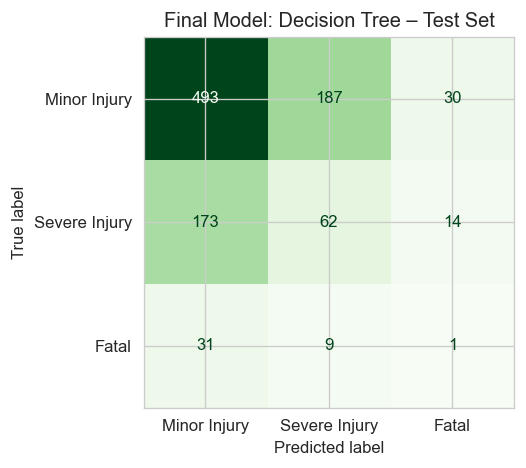

In [213]:
print(f'Retraining: {best_name}  on full training set ({len(X_full)} rows)')
needs_scaling = best_name in ['KNN','Logistic Regression','Naive Bayes']

final_scaler = StandardScaler()
X_full_sc    = final_scaler.fit_transform(X_full)
X_test_sc_f  = final_scaler.transform(X_test_final)

final_model = copy.deepcopy(results_summary[best_name]['model'])
if needs_scaling:
    final_model.fit(X_full_sc, y_full)
    final_preds = final_model.predict(X_test_sc_f)
else:
    final_model.fit(X_full, y_full)
    final_preds = final_model.predict(X_test_final)

final_acc = accuracy_score(y_test_final, final_preds)
final_f1w = f1_score(y_test_final, final_preds, average='weighted')
final_f1m = f1_score(y_test_final, final_preds, average='macro')

print(f'\n=== FINAL TEST SET PERFORMANCE ===')
print(f'  Accuracy    : {final_acc:.4f}')
print(f'  F1 Weighted : {final_f1w:.4f}')
print(f'  F1 Macro    : {final_f1m:.4f}')
print()
print(classification_report(y_test_final, final_preds, target_names=CLASS_NAMES))

fig, ax = plt.subplots(figsize=(6,4))
ConfusionMatrixDisplay.from_predictions(
    y_test_final, final_preds, display_labels=CLASS_NAMES,
    ax=ax, colorbar=False, cmap='Greens')
ax.set_title(f'Final Model: {best_name} – Test Set')
plt.tight_layout(); plt.show()

### Cell 29 – Generate Submission CSV

In [214]:
# Map numeric predictions back to string labels
final_preds_labels = [label_unmap[p] for p in final_preds]

# sample_submission has 5000 rows (train 4000 + test 1000).
# Use the last 1000 IDs which correspond to the test set rows.
submission = pd.DataFrame({
    'ID'                : sub['ID'].values[-len(final_preds_labels):],
    'Predicted_Severity': final_preds_labels
})
submission.to_csv('submission.csv', index=False)
print('submission.csv saved ✅')
print('\nPrediction distribution:')
print(submission['Predicted_Severity'].value_counts())
submission.head(10)

submission.csv saved ✅

Prediction distribution:
Predicted_Severity
Minor Injury     697
Severe Injury    258
Fatal             45
Name: count, dtype: int64


,ID,Predicted_Severity
0,cd4fad27-ba6a-41c0-b2b0-0521cb8fa92a,Severe Injury
1,5d6dccb9-a758-44f5-b33a-4bef19959106,Minor Injury
2,81cd50d5-5f09-476a-a719-95abeea1c8ed,Minor Injury
3,b9a43e63-2bc8-427e-8d1e-3be7656a8080,Severe Injury
4,17a84002-3539-46ec-9bd7-ce1710ccd531,Minor Injury
5,85acbcea-0a3e-43bb-8474-df2fdbad9453,Minor Injury
6,14e75f82-5d82-4672-b2c2-43c90de30809,Minor Injury
7,a0cfc3e5-7999-42c4-a7ee-3f730bcb2f0e,Minor Injury
8,3a328b5d-2260-4c58-984e-445d6cb27219,Severe Injury
9,0c7c7fae-fb5b-46d7-95b3-ec949aacb5d6,Minor Injury


---
##  Section 11 – Conclusion

### Dataset-Specific Findings

| Finding | Detail |
|---|---|
| **Missing values** | Only `Distraction Level` (~59%) — filled with `'None'` (semantic fill, not mode) |
| **Outliers** | None detected via IQR — no capping or removal needed |
| **Class imbalance** | Fatal 5.2% — use F1-Macro as primary metric, not accuracy |
| **Key predictors** | Crash Speed, BAC, Airbag/Seatbelt use, Brake/Tire condition |

### Model Summary

| Model | Scaling? | Strengths | Weaknesses |
|---|---|---|---|
| **KNN** | ✅ | Simple, no training phase, intuitive | Slow at inference, sensitive to K |
| **Decision Tree** | ❌ | Interpretable, fast | Overfits without pruning |
| **Random Forest** | ❌ | High accuracy, robust, feature importance | Less interpretable |
| **Logistic Regression** | ✅ | Probabilistic, fast, linear baseline | Struggles with non-linear boundaries |
| **Naïve Bayes** | ✅ | Fastest, low memory | Independence + Gaussian assumptions violated |

### Evaluation Approach
- All hyperparameters tuned with **5-fold cross-validation** on training data only
- Test set touched exactly **once** — for the final retrained model evaluation
- Because the dataset is highly imbalanced, evaluation focused on
    multiple metrics including F1-weighted, Macro F1, Balanced Accuracy,
    and per-class recall to better assess minority-class performance.
- The **Fatal** class is consistently hardest to classify across all models